# Use Real Images for Processing or Somethin

This notebook runs MPI-based image processing using C++ (CUDA + MPI + OpenMP).

We dynamically pass images into the parallel program and test performance across multiple processor counts.

but yea that how it works idk

In [1]:
import subprocess
import re
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os
print(os.getcwd())

c:\Users\nyoma\Downloads\mpyCUDA\CUDA-Speedup-Law


In [ ]:
procs = [1, 2, 4, 6, 8, 16, 24, 30, 48]
times_blur = []
times_edge = []

input_img = r"./images/input.jpg"
output_prefix = r"./images/output"

In [4]:
for p in procs:

    cmd = [
        r"C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe",
        "-n", str(p),
        r"./scripts/parallel_image.exe",
        input_img,
        f"{output_prefix}_blur_{p}.jpg",
        "blur"
    ]

    print("Running:", " ".join(cmd))

    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout)
    print(result.stderr)

    out = subprocess.check_output(cmd).decode()

    print(out)

    t = float(re.findall(r"Time taken: ([0-9.]+)", out)[0])
    times_blur.append(t)

times_blur

Running: C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe -n 1 ./scripts/parallel_image.exe ./images/input.jpg ./images/output_blur_1.jpg blur
Rank 0 started
Image Logic: 985x1613 channels: 3 Mode: blur with 1 ranks.
Using GUIDED scheduling for load balancing.
Time taken: 0.000069
Rank 0 finished

Please run with at least 2 ranks for Master-Worker logic.

Rank 0 started
Image Logic: 985x1613 channels: 3 Mode: blur with 1 ranks.
Using GUIDED scheduling for load balancing.
Time taken: 0.000061
Rank 0 finished

Running: C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe -n 2 ./scripts/parallel_image.exe ./images/input.jpg ./images/output_blur_2.jpg blur
Rank 0 started
Image Logic: 985x1613 channels: 3 Mode: blur with 2 ranks.
Using GUIDED scheduling for load balancing.
Time taken: 0.138269
Rank 0 finished
Rank 1 started
Rank 1 processing rows 0 to 805
Rank 1 processing rows 806 to 1208
Rank 1 processing rows 1209 to 1410
Rank 1 processing rows 1411 to 1511
Rank 1 processing rows 1512 to

[6.1e-05, 0.112849, 0.188086, 0.371826, 0.849934, 1.409335, 1.774695]

In [5]:
for p in procs:

    cmd = [
        r"C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe",
        "-n", str(p),
        r"./scripts/parallel_image.exe",
        input_img,
        f"{output_prefix}_edge_{p}.jpg",
        "edge"
    ]

    print("Running:", " ".join(cmd))

    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout)
    print(result.stderr)

    out = subprocess.check_output(cmd).decode()

    print(out)

    t = float(re.findall(r"Time taken: ([0-9.]+)", out)[0])
    times_edge.append(t)

times_edge

Running: C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe -n 1 ./scripts/parallel_image.exe ./images/input.jpg ./images/output_edge_1.jpg edge
Rank 0 started
Image Logic: 985x1613 channels: 3 Mode: edge with 1 ranks.
Using GUIDED scheduling for load balancing.
Time taken: 0.000128
Rank 0 finished

Please run with at least 2 ranks for Master-Worker logic.

Rank 0 started
Image Logic: 985x1613 channels: 3 Mode: edge with 1 ranks.
Using GUIDED scheduling for load balancing.
Time taken: 0.000088
Rank 0 finished

Running: C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe -n 2 ./scripts/parallel_image.exe ./images/input.jpg ./images/output_edge_2.jpg edge
Rank 0 started
Image Logic: 985x1613 channels: 3 Mode: edge with 2 ranks.
Using GUIDED scheduling for load balancing.
Time taken: 0.207863
Rank 0 finished
Rank 1 started
Rank 1 processing rows 0 to 805
Rank 1 processing rows 806 to 1208
Rank 1 processing rows 1209 to 1410
Rank 1 processing rows 1411 to 1511
Rank 1 processing rows 1512 to

[8.8e-05, 0.104515, 0.171725, 0.380397, 0.915556, 1.510677, 1.549499]

In [6]:
times_blur = np.array(times_blur)
speedup_blur = times_blur[0] / times_blur
times_edge = np.array(times_edge)
speedup_edge = times_edge[0] / times_edge

speedup_blur
speedup_edge

array([1.00000000e+00, 8.41984404e-04, 5.12447227e-04, 2.31337261e-04,
       9.61164582e-05, 5.82520287e-05, 5.67925504e-05])

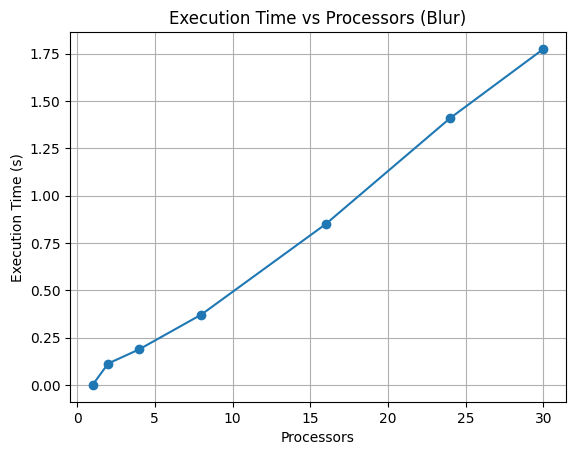

In [7]:
plt.figure()

plt.plot(procs, times_blur, marker='o')
plt.xlabel("Processors")
plt.ylabel("Execution Time (s)")
plt.title("Execution Time vs Processors (Blur)")

plt.grid()
plt.show()

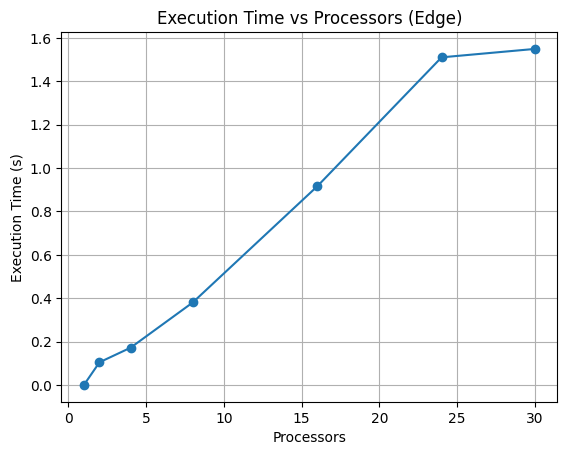

In [8]:
plt.figure()

plt.plot(procs, times_edge, marker='o')
plt.xlabel("Processors")
plt.ylabel("Execution Time (s)")
plt.title("Execution Time vs Processors (Edge)")

plt.grid()
plt.show()

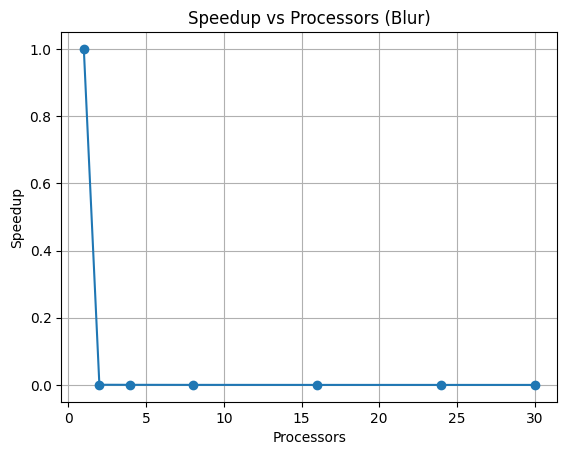

In [9]:
plt.figure()

plt.plot(procs, speedup_blur, marker='o')

plt.xlabel("Processors")
plt.ylabel("Speedup")

plt.title("Speedup vs Processors (Blur)")

plt.grid()
plt.show()

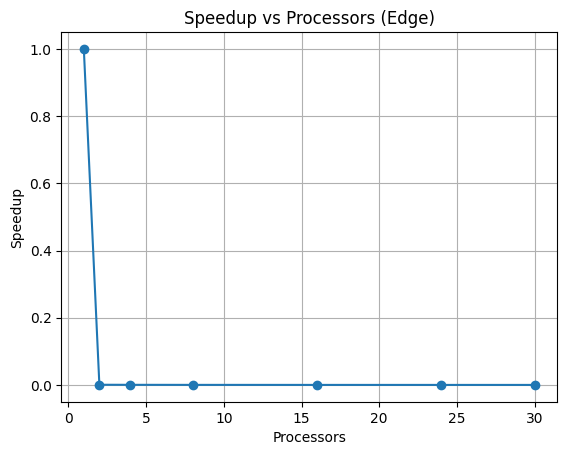

In [10]:
plt.figure()

plt.plot(procs, speedup_blur, marker='o')

plt.xlabel("Processors")
plt.ylabel("Speedup")

plt.title("Speedup vs Processors (Edge)")

plt.grid()
plt.show()